# **Neural Network**

## Import packages and dataset

Our first step is to import the neccessary packages and

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

Now, I will importthe dataset usinh GitHub RAW URL.

In [146]:
GITHUB_RAW_URL = "https://raw.githubusercontent.com/mdraihan27/neural-network/refs/heads/main/dataset/diabetes.csv"

try:
    df = pd.read_csv(GITHUB_RAW_URL)
    print("Dataset successfully loaded from GitHub.")
except Exception as e:
    print(f"Failed to load dataset. Check your raw URL. Error: {e}")
    raise

Dataset successfully loaded from GitHub.


## Exploratory Data Analysis

Let's view the shape and some of the rows from the dataset.

In [147]:
print("\n=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== First 5 Rows ===")
display(df.head())

print("\n=== Data Types & Non-Null Counts ===")
print(df.info())

print("\n=== Basic Statistical Summary ===")
display(df.describe())


=== Dataset Shape ===
Rows: 768, Columns: 9

=== First 5 Rows ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

=== Basic Statistical Summary ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Let's check for missing values.

In [148]:
print("\n[2.2] Missing Values Check")
print("-"*40)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No explicit NaN values found.")
else:
    print(missing[missing > 0])


[2.2] Missing Values Check
----------------------------------------
No explicit NaN values found.


Let's check for zero values.

In [149]:
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    zero_count = (df[col] == 0).sum()
    zero_pct = (zero_count / len(df)) * 100
    print(f"{col}: {zero_count} zeros ({zero_pct:.2f}%)")


Glucose: 5 zeros (0.65%)
BloodPressure: 35 zeros (4.56%)
SkinThickness: 227 zeros (29.56%)
Insulin: 374 zeros (48.70%)
BMI: 11 zeros (1.43%)


Let's View target variable distribution.

In [150]:
print("\n[2.5] Target Variable Distribution (Outcome)")
print("-"*40)
outcome_counts = df['Outcome'].value_counts()
print(f"Class 0 (No Diabetes): {outcome_counts[0]} samples ({outcome_counts[0]/len(df)*100:.2f}%)")
print(f"Class 1 (Diabetes): {outcome_counts[1]} samples ({outcome_counts[1]/len(df)*100:.2f}%)")


[2.5] Target Variable Distribution (Outcome)
----------------------------------------
Class 0 (No Diabetes): 500 samples (65.10%)
Class 1 (Diabetes): 268 samples (34.90%)


Let's view different variables correlation with target.

In [151]:
correlations = df.corr()['Outcome'].sort_values(ascending=False)
display(correlations)

,Outcome
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


Let;s visualize feature distribution.


[2.7] Visualizing Feature Distributions
----------------------------------------


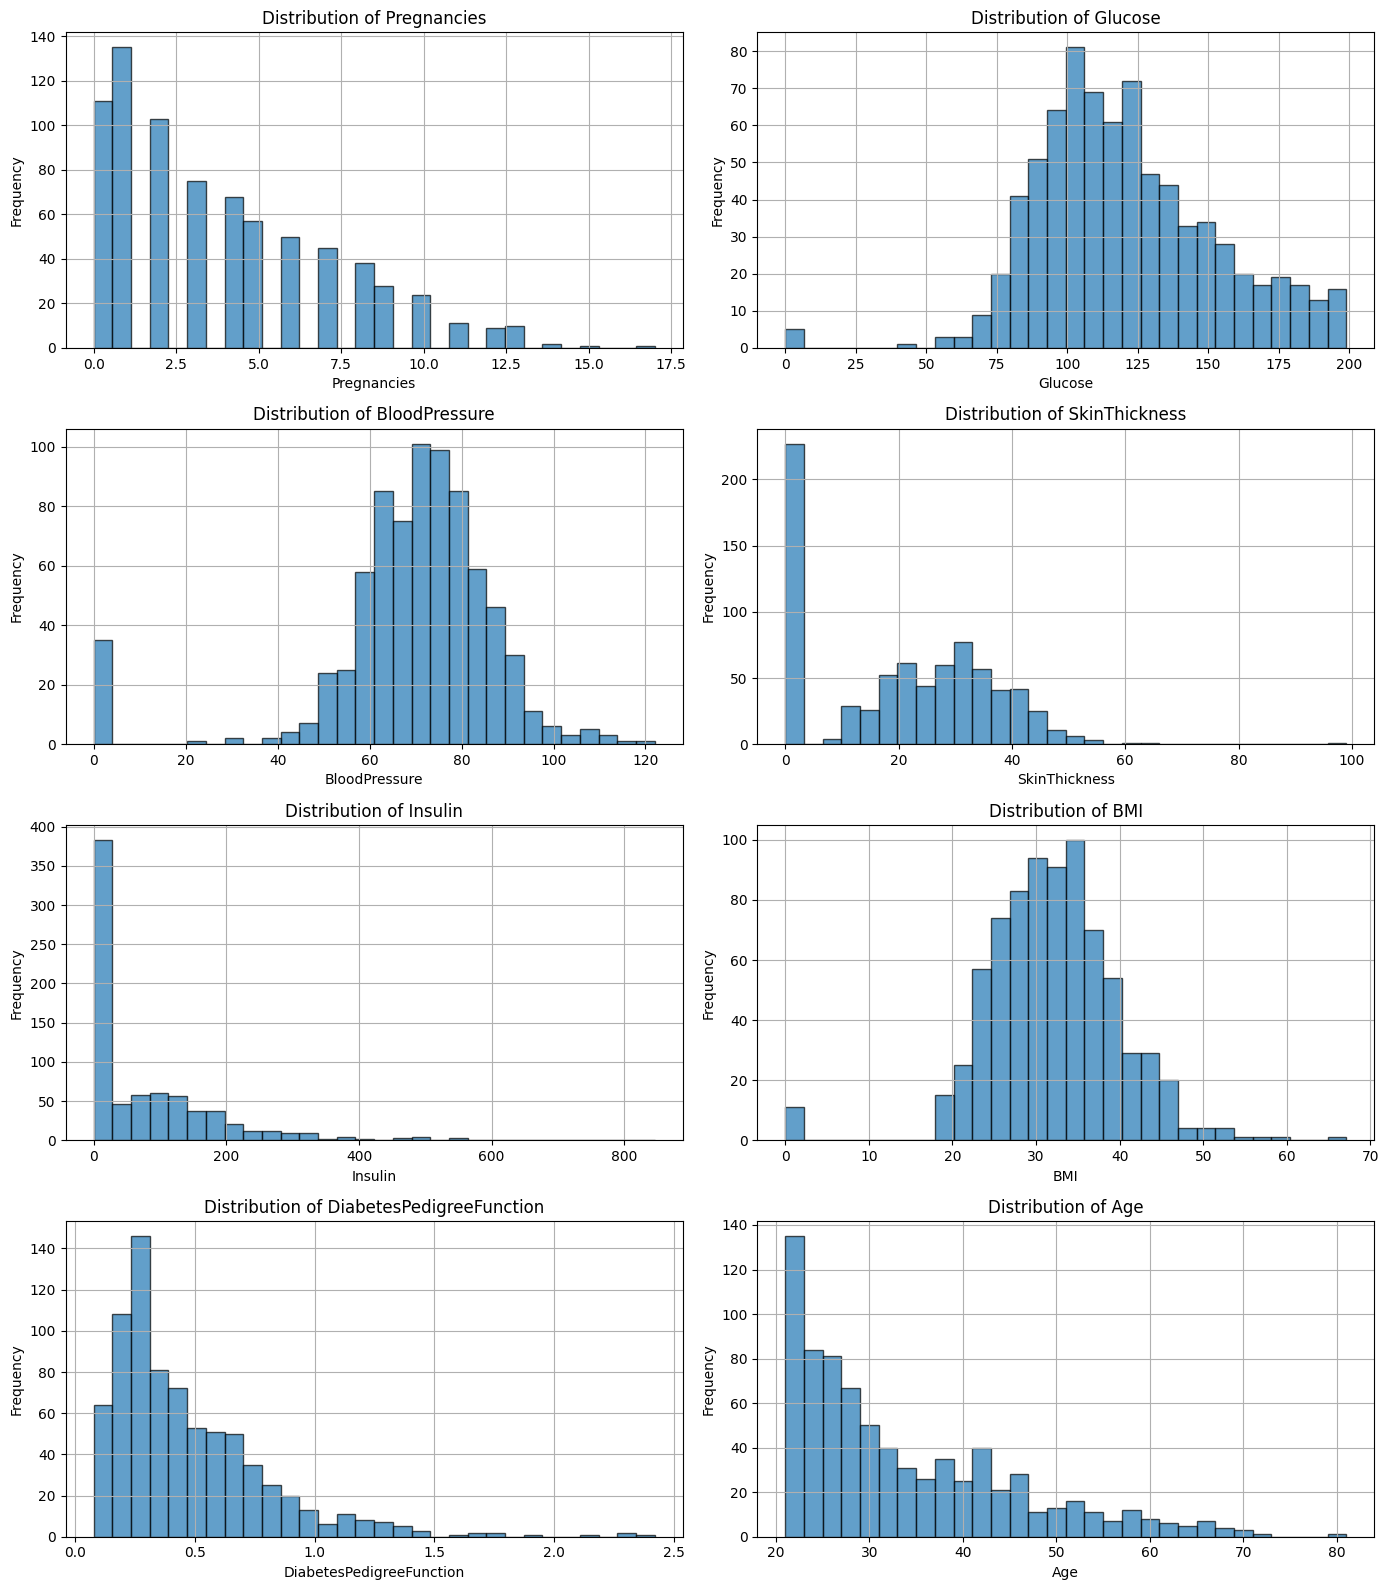

In [152]:
print("\n[2.7] Visualizing Feature Distributions")
print("-"*40)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(df.columns[:-1]):  # exclude 'Outcome'
    df[col].hist(ax=axes[i], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Let's detect outliers using boxplots.


[2.8] Outlier Detection (Boxplots)
----------------------------------------


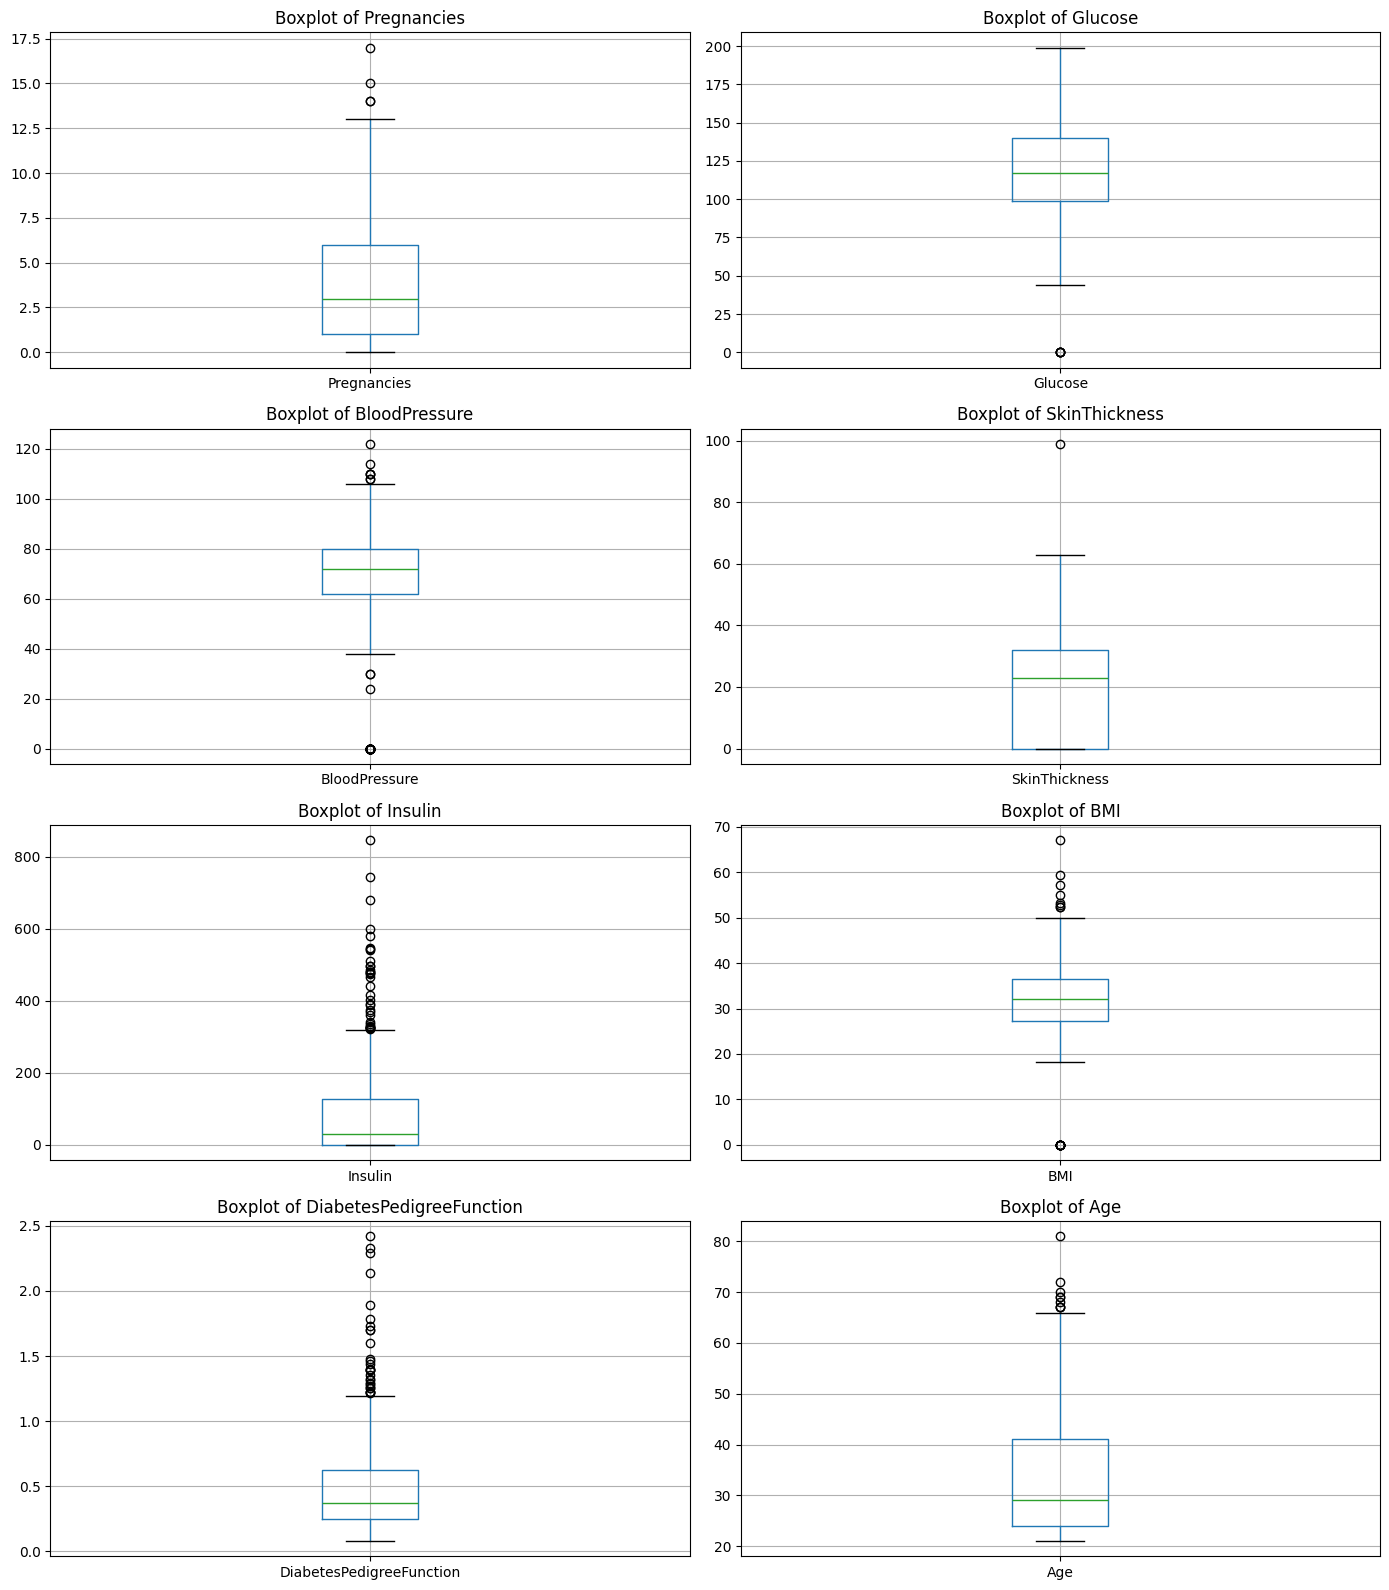

In [153]:
print("\n[2.8] Outlier Detection (Boxplots)")
print("-"*40)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(df.columns[:-1]):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

Let's view pairplots .

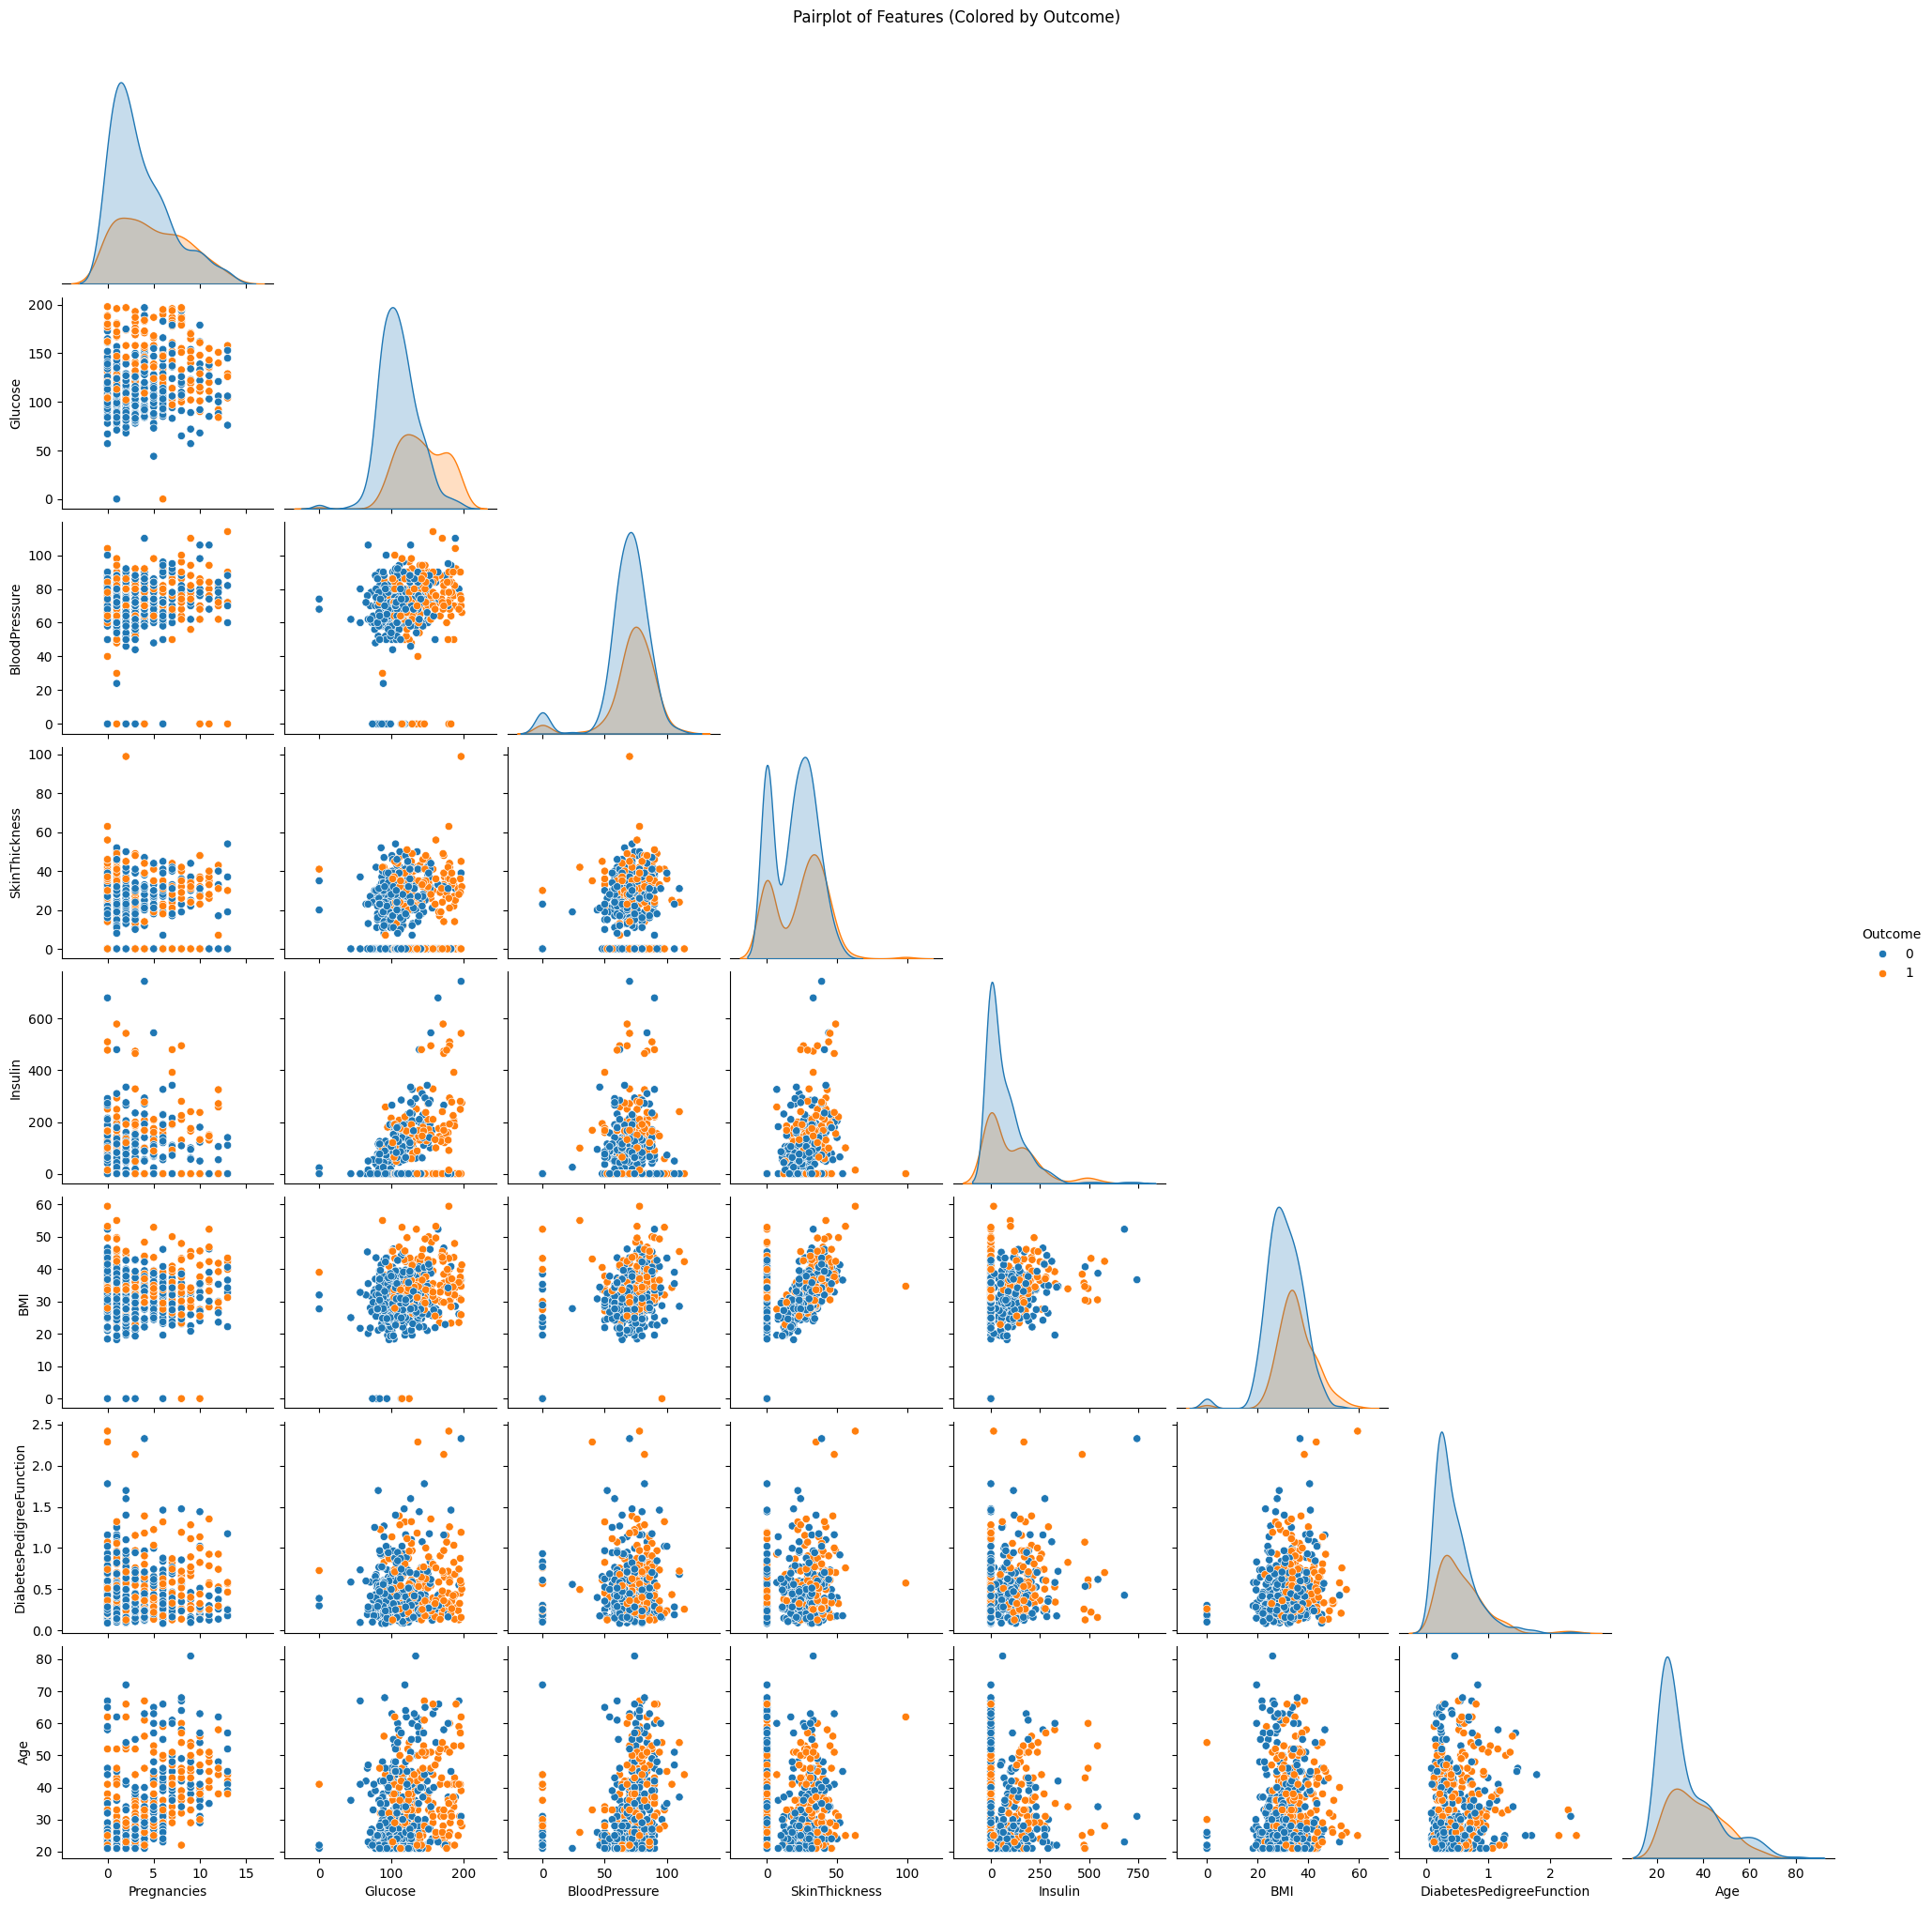

In [154]:
if len(df) > 500:
    sample_df = df.sample(500)
else:
    sample_df = df
sns.pairplot(sample_df, hue='Outcome', diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Features (Colored by Outcome)', y=1.02)
plt.show()

### Now, we will perform data preprocessing.

Create a copy to avoid modifying original.

In [155]:
df_processed = df.copy()
print(f"\n[3.1] Starting with {df_processed.shape[0]} samples, {df_processed.shape[1]} features")


[3.1] Starting with 768 samples, 9 features


Columns that should not have zero columns.

In [156]:
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

Let's count zeros.

In [157]:
for col in zero_columns:
    zero_count = (df_processed[col] == 0).sum()
    print(f"  {col}: {zero_count} zeros")

  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros


Let's replace zero with the median of it's column.

In [158]:
for col in zero_columns:
    median_val = df_processed[col][df_processed[col] > 0].median()
    df_processed[col] = df_processed[col].replace(0, median_val)
    print(f"  {col}: Imputed with median = {median_val:.2f}")

  Glucose: Imputed with median = 117.00
  BloodPressure: Imputed with median = 72.00
  SkinThickness: Imputed with median = 29.00
  Insulin: Imputed with median = 125.00
  BMI: Imputed with median = 32.30


Let's verify that no zeroes exist.

In [159]:
print("\nZeros after imputation:")
for col in zero_columns:
    zero_count = (df_processed[col] == 0).sum()
    print(f"  {col}: {zero_count} zeros")


Zeros after imputation:
  Glucose: 0 zeros
  BloodPressure: 0 zeros
  SkinThickness: 0 zeros
  Insulin: 0 zeros
  BMI: 0 zeros


Let's create categorical features for better accuracy.

For BMI

In [160]:
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_processed['BMI_Category'] = pd.cut(df_processed['BMI'], bins=bmi_bins, labels=bmi_labels)

For Age

In [161]:
age_bins = [0, 30, 40, 50, 60, 120]
age_labels = ['<30', '30-40', '40-50', '50-60', '60+']
df_processed['Age_Category'] = pd.cut(df_processed['Age'], bins=age_bins, labels=age_labels)

For Glucose

In [162]:
glucose_bins = [0, 100, 126, 200, 300]
glucose_labels = ['Normal', 'Pre-diabetic', 'Diabetic', 'High Diabetic']
df_processed['Glucose_Category'] = pd.cut(df_processed['Glucose'], bins=glucose_bins, labels=glucose_labels)

Let's encode these categorical features using one hot encoding.

In [163]:
categorical_cols = ['BMI_Category', 'Age_Category', 'Glucose_Category']
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=False)


print(f"Original features: {df_processed.shape[1]}")
print(f"After one-hot encoding: {df_encoded.shape[1]} features")

bool_cols = df_encoded.select_dtypes(include=['bool']).columns
print(f"Found {len(bool_cols)} boolean columns")
for col in bool_cols:
    df_encoded[col] = df_encoded[col].astype(int)
    print(f"  ✓ Converted {col} to int")

Original features: 12
After one-hot encoding: 22 features
Found 13 boolean columns
  ✓ Converted BMI_Category_Underweight to int
  ✓ Converted BMI_Category_Normal to int
  ✓ Converted BMI_Category_Overweight to int
  ✓ Converted BMI_Category_Obese to int
  ✓ Converted Age_Category_<30 to int
  ✓ Converted Age_Category_30-40 to int
  ✓ Converted Age_Category_40-50 to int
  ✓ Converted Age_Category_50-60 to int
  ✓ Converted Age_Category_60+ to int
  ✓ Converted Glucose_Category_Normal to int
  ✓ Converted Glucose_Category_Pre-diabetic to int
  ✓ Converted Glucose_Category_Diabetic to int
  ✓ Converted Glucose_Category_High Diabetic to int


Let's separate features and target.

In [164]:
X = df_encoded.drop('Outcome', axis=1)
y = df_encoded['Outcome']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class distribution in y:\n{y.value_counts()}")

Features shape: (768, 21)
Target shape: (768,)
Class distribution in y:
Outcome
0    500
1    268
Name: count, dtype: int64


Let's perform feature scaling.

In [165]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("\n[3.7] Stratified Train-Validation-Test Split")
print("-"*40)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=None
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    stratify=y_temp,
    random_state=None
)




[3.7] Stratified Train-Validation-Test Split
----------------------------------------


Let's split the data into train and test.

In [166]:
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\n[3.8] Feature Scaling (After Split)")
print("-"*40)

numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled = X_val.copy()
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"✓ Scaler fitted on training data only")

print("\n[3.9] Converting to Tensors")
print("-"*40)

X_train_tensor = torch.FloatTensor(X_train_scaled.values.astype(np.float64))
X_val_tensor = torch.FloatTensor(X_val_scaled.values.astype(np.float64))
X_test_tensor = torch.FloatTensor(X_test_scaled.values.astype(np.float64))
y_train_tensor = torch.FloatTensor(y_train.values.astype(np.float64)).reshape(-1, 1)
y_val_tensor = torch.FloatTensor(y_val.values.astype(np.float64)).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values.astype(np.float64)).reshape(-1, 1)

print(f"✓ X_train_tensor shape: {X_train_tensor.shape}")
print(f"✓ X_val_tensor shape: {X_val_tensor.shape}")
print(f"✓ X_test_tensor shape: {X_test_tensor.shape}")
print(f"✓ y_train_tensor shape: {y_train_tensor.shape}")
print(f"✓ y_val_tensor shape: {y_val_tensor.shape}")
print(f"✓ y_test_tensor shape: {y_test_tensor.shape}")

Training set: 491 samples (63.9%)
Validation set: 123 samples (16.0%)
Test set: 154 samples (20.1%)

[3.8] Feature Scaling (After Split)
----------------------------------------
✓ Scaler fitted on training data only

[3.9] Converting to Tensors
----------------------------------------
✓ X_train_tensor shape: torch.Size([491, 21])
✓ X_val_tensor shape: torch.Size([123, 21])
✓ X_test_tensor shape: torch.Size([154, 21])
✓ y_train_tensor shape: torch.Size([491, 1])
✓ y_val_tensor shape: torch.Size([123, 1])
✓ y_test_tensor shape: torch.Size([154, 1])


## **Implementation of Shallow Neural Network with hyperparameter tuning.**

Define shallow network architechture.

In [167]:
class ShallowNN(nn.Module):
    def __init__(self, input_dim, hidden_units, activation):
        super(ShallowNN, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_units)

        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            self.activation = nn.ReLU()

        self.fc2 = nn.Linear(hidden_units, 1)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.output_activation(x)
        return x

Create validation split from training data.

In [168]:

VAL_RATIO  = 0.2
val_size   = int(len(X_train_tensor) * VAL_RATIO)
train_size = len(X_train_tensor) - val_size

full_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_sub, val_sub = random_split(
    full_train_dataset,
    [train_size, val_size]
)

print(f"Tuning split → train: {train_size}  |  val: {val_size}")

Tuning split → train: 393  |  val: 98


Training function.

In [169]:
def train_model(model, train_loader, val_loader, epochs, learning_rate, device):
    """Train a PyTorch model and return training history"""

    model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            predicted = (outputs > 0.5).float()
            train_correct += (predicted == y_batch).sum().item()
            train_total += y_batch.size(0)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)

                    val_loss += loss.item() * X_batch.size(0)
                    predicted = (outputs > 0.5).float()
                    val_correct += (predicted == y_batch).sum().item()
                    val_total += y_batch.size(0)

            history['val_loss'].append(val_loss / val_total)
            history['val_acc'].append(val_correct / val_total)
        else:
            # If no validation, append None or last value
            history['val_loss'].append(None)
            history['val_acc'].append(None)

        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_correct / train_total)

        if (epoch + 1) % 10 == 0:
            if val_loader is not None:
                print(f"Epoch {epoch+1}/{epochs} - "
                      f"Train Loss: {history['train_loss'][-1]:.4f}, "
                      f"Train Acc: {history['train_acc'][-1]:.4f}, "
                      f"Val Loss: {history['val_loss'][-1]:.4f}, "
                      f"Val Acc: {history['val_acc'][-1]:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs} - "
                      f"Train Loss: {history['train_loss'][-1]:.4f}, "
                      f"Train Acc: {history['train_acc'][-1]:.4f}")

    return history

Hyper parameter tuning.

In [170]:
hidden_units_options = [16, 32, 64, 128]
activation_options = ['relu', 'sigmoid', 'tanh']
batch_size_options = [16, 32, 64]
learning_rate = 0.001
epochs = 50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Input dimension: {X_train_tensor.shape[1]}")

tuning_results = []
best_val_acc = 0
best_params = {}

print("\nStarting hyperparameter tuning...")
print("-"*40)

for hidden_units in hidden_units_options:
    for activation in activation_options:
        for batch_size in batch_size_options:

            print(f"\nTesting: hidden={hidden_units}, activation={activation}, batch_size={batch_size}")

            train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
            val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

            model = ShallowNN(
                input_dim=X_train_tensor.shape[1],
                hidden_units=hidden_units,
                activation=activation
            )

            history = train_model(
                model, train_loader, val_loader,
                epochs=epochs, learning_rate=learning_rate,
                device=device
            )

            final_val_acc = history['val_acc'][-1]

            tuning_results.append({
                'hidden_units': hidden_units,
                'activation': activation,
                'batch_size': batch_size,
                'val_acc': final_val_acc,
                'history': history
            })

            print(f"  ✓ Final Val Acc: {final_val_acc:.4f}")

            if final_val_acc > best_val_acc:
                best_val_acc = final_val_acc
                best_params = {
                    'hidden_units': hidden_units,
                    'activation': activation,
                    'batch_size': batch_size
                }
                best_model = model
                best_history = history

print("\n" + "="*60)
print("HYPERPARAMETER TUNING COMPLETE")
print("="*60)
print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Parameters:")
print(f"  - Hidden Units: {best_params['hidden_units']}")
print(f"  - Activation: {best_params['activation']}")
print(f"  - Batch Size: {best_params['batch_size']}")

Using device: cpu
Input dimension: 21

Starting hyperparameter tuning...
----------------------------------------

Testing: hidden=16, activation=relu, batch_size=16
Epoch 10/50 - Train Loss: 0.4441, Train Acc: 0.7821, Val Loss: 0.5032, Val Acc: 0.7561
Epoch 20/50 - Train Loss: 0.4052, Train Acc: 0.8208, Val Loss: 0.5101, Val Acc: 0.7398
Epoch 30/50 - Train Loss: 0.3888, Train Acc: 0.8208, Val Loss: 0.5176, Val Acc: 0.7154
Epoch 40/50 - Train Loss: 0.3775, Train Acc: 0.8330, Val Loss: 0.5240, Val Acc: 0.7154
Epoch 50/50 - Train Loss: 0.3680, Train Acc: 0.8248, Val Loss: 0.5299, Val Acc: 0.6992
  ✓ Final Val Acc: 0.6992

Testing: hidden=16, activation=relu, batch_size=32
Epoch 10/50 - Train Loss: 0.4460, Train Acc: 0.7902, Val Loss: 0.4932, Val Acc: 0.7317
Epoch 20/50 - Train Loss: 0.4076, Train Acc: 0.8024, Val Loss: 0.4895, Val Acc: 0.7480
Epoch 30/50 - Train Loss: 0.3908, Train Acc: 0.8228, Val Loss: 0.4998, Val Acc: 0.7398
Epoch 40/50 - Train Loss: 0.3813, Train Acc: 0.8248, Val Los

Finally, train the shallow model.

In [171]:
X_train_full = torch.cat([X_train_tensor, X_val_tensor], dim=0)
y_train_full = torch.cat([y_train_tensor, y_val_tensor], dim=0)

train_full_dataset = TensorDataset(X_train_full, y_train_full)
train_full_loader = DataLoader(
    train_full_dataset,
    batch_size=best_params['batch_size'],
    shuffle=True
)

final_shallow_model = ShallowNN(
    input_dim=X_train_tensor.shape[1],
    hidden_units=best_params['hidden_units'],
    activation=best_params['activation']
)

print(f"Training final shallow model with best parameters...")
print(f"  - Hidden Units: {best_params['hidden_units']}")
print(f"  - Activation: {best_params['activation']}")
print(f"  - Batch Size: {best_params['batch_size']}")
print(f"  - Training samples: {X_train_full.shape[0]}")

final_history = train_model(
    final_shallow_model,
    train_full_loader,
    val_loader=None,
    epochs=100,
    learning_rate=learning_rate,
    device=device
)

Training final shallow model with best parameters...
  - Hidden Units: 64
  - Activation: sigmoid
  - Batch Size: 16
  - Training samples: 614
Epoch 10/100 - Train Loss: 0.4611, Train Acc: 0.7720
Epoch 20/100 - Train Loss: 0.4369, Train Acc: 0.7801
Epoch 30/100 - Train Loss: 0.4299, Train Acc: 0.7850
Epoch 40/100 - Train Loss: 0.4289, Train Acc: 0.7850
Epoch 50/100 - Train Loss: 0.4247, Train Acc: 0.7932
Epoch 60/100 - Train Loss: 0.4241, Train Acc: 0.7948
Epoch 70/100 - Train Loss: 0.4223, Train Acc: 0.7932
Epoch 80/100 - Train Loss: 0.4218, Train Acc: 0.7932
Epoch 90/100 - Train Loss: 0.4195, Train Acc: 0.7948
Epoch 100/100 - Train Loss: 0.4175, Train Acc: 0.7980


# **Deep Neural Network with hyper-parameter-tuning**

In [172]:
print("="*60)
print("DEEP NEURAL NETWORK - HYPERPARAMETER TUNING")
print("="*60)

class DeepNN(nn.Module):
    def __init__(self, input_dim, hidden_units, activation, dropout_rate=0.3):
        super(DeepNN, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        self.fc3 = nn.Linear(hidden_units, hidden_units)
        self.fc4 = nn.Linear(hidden_units, 1)

        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            self.activation = nn.ReLU()

        self.dropout = nn.Dropout(dropout_rate)

        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc3(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc4(x)
        x = self.output_activation(x)

        return x

def train_model_deep(model, train_loader, val_loader, epochs, learning_rate,
                     optimizer_name, weight_decay, device):
    """Train deep model with L2 regularization support"""

    model.to(device)
    criterion = nn.BCELoss()

    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            predicted = (outputs > 0.5).float()
            train_correct += (predicted == y_batch).sum().item()
            train_total += y_batch.size(0)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)

                    val_loss += loss.item() * X_batch.size(0)
                    predicted = (outputs > 0.5).float()
                    val_correct += (predicted == y_batch).sum().item()
                    val_total += y_batch.size(0)

            history['val_loss'].append(val_loss / val_total)
            history['val_acc'].append(val_correct / val_total)
        else:
            history['val_loss'].append(None)
            history['val_acc'].append(None)

        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_correct / train_total)

        if (epoch + 1) % 10 == 0:
            if val_loader is not None:
                print(f"Epoch {epoch+1}/{epochs} - "
                      f"Train Loss: {history['train_loss'][-1]:.4f}, "
                      f"Train Acc: {history['train_acc'][-1]:.4f}, "
                      f"Val Loss: {history['val_loss'][-1]:.4f}, "
                      f"Val Acc: {history['val_acc'][-1]:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs} - "
                      f"Train Loss: {history['train_loss'][-1]:.4f}, "
                      f"Train Acc: {history['train_acc'][-1]:.4f}")

    return history


print("\n[5.1] Hyperparameter Tuning for Deep Network")
print("-"*40)


hidden_units_options = [32, 64, 128]
activation_options = ['relu', 'tanh']
learning_rate_options = [0.001, 0.0005, 0.0001]
optimizer_options = ['adam', 'sgd']
dropout_rates = [0.2, 0.3, 0.5]
batch_size = 32
epochs = 50
weight_decay = 0.0001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Input dimension: {X_train_tensor.shape[1]}")


hidden_units_to_test = [64, 128]
learning_rates_to_test = [0.001, 0.0001]
optimizers_to_test = ['adam', 'sgd']
dropout_to_test = [0.3, 0.5]

tuning_results_deep = []
best_val_acc_deep = 0
best_params_deep = {}

print("\nStarting hyperparameter tuning for deep network...")
print("NOTE: This may take several minutes...")
print("-"*40)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

for hidden_units in hidden_units_to_test:
    for activation in activation_options:
        for lr in learning_rates_to_test:
            for optimizer_name in optimizers_to_test:
                for dropout_rate in dropout_to_test:

                    print(f"\nTesting: hidden={hidden_units}, activation={activation}, "
                          f"lr={lr}, optimizer={optimizer_name}, dropout={dropout_rate}")

                    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

                    model = DeepNN(
                        input_dim=X_train_tensor.shape[1],
                        hidden_units=hidden_units,
                        activation=activation,
                        dropout_rate=dropout_rate
                    )

                    history = train_model_deep(
                        model, train_loader, val_loader,
                        epochs=epochs,
                        learning_rate=lr,
                        optimizer_name=optimizer_name,
                        weight_decay=weight_decay,
                        device=device
                    )

                    final_val_acc = history['val_acc'][-1]

                    tuning_results_deep.append({
                        'hidden_units': hidden_units,
                        'activation': activation,
                        'learning_rate': lr,
                        'optimizer': optimizer_name,
                        'dropout_rate': dropout_rate,
                        'val_acc': final_val_acc,
                        'history': history
                    })

                    print(f"  ✓ Final Val Acc: {final_val_acc:.4f}")

                    if final_val_acc > best_val_acc_deep:
                        best_val_acc_deep = final_val_acc
                        best_params_deep = {
                            'hidden_units': hidden_units,
                            'activation': activation,
                            'learning_rate': lr,
                            'optimizer': optimizer_name,
                            'dropout_rate': dropout_rate
                        }
                        best_model_deep = model
                        best_history_deep = history

print("\n" + "="*60)
print("DEEP NETWORK HYPERPARAMETER TUNING COMPLETE")
print("="*60)
print(f"\nBest Validation Accuracy: {best_val_acc_deep:.4f}")
print(f"Best Parameters:")
print(f"  - Hidden Units: {best_params_deep['hidden_units']}")
print(f"  - Activation: {best_params_deep['activation']}")
print(f"  - Learning Rate: {best_params_deep['learning_rate']}")
print(f"  - Optimizer: {best_params_deep['optimizer']}")
print(f"  - Dropout Rate: {best_params_deep['dropout_rate']}")

print("\n[5.2] Training Final Deep Model")
print("-"*40)

X_train_full = torch.cat([X_train_tensor, X_val_tensor], dim=0)
y_train_full = torch.cat([y_train_tensor, y_val_tensor], dim=0)

train_full_dataset = TensorDataset(X_train_full, y_train_full)
train_full_loader = DataLoader(
    train_full_dataset,
    batch_size=batch_size,
    shuffle=True
)

final_deep_model = DeepNN(
    input_dim=X_train_tensor.shape[1],
    hidden_units=best_params_deep['hidden_units'],
    activation=best_params_deep['activation'],
    dropout_rate=best_params_deep['dropout_rate']
)

print(f"Training final deep model with best parameters...")
print(f"  - Hidden Units: {best_params_deep['hidden_units']}")
print(f"  - Activation: {best_params_deep['activation']}")
print(f"  - Learning Rate: {best_params_deep['learning_rate']}")
print(f"  - Optimizer: {best_params_deep['optimizer']}")
print(f"  - Dropout Rate: {best_params_deep['dropout_rate']}")
print(f"  - Training samples: {X_train_full.shape[0]}")

final_history_deep = train_model_deep(
    final_deep_model,
    train_full_loader,
    val_loader=None,
    epochs=100,
    learning_rate=best_params_deep['learning_rate'],
    optimizer_name=best_params_deep['optimizer'],
    weight_decay=weight_decay,
    device=device
)

print("\n✓ Final deep model training complete!")

print("\n[5.3] Evaluating Deep Model on Test Set")
print("-"*40)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

final_deep_model.eval()
test_predictions_deep = []
test_probabilities_deep = []
test_targets_deep = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = final_deep_model(X_batch)
        test_probabilities_deep.extend(outputs.cpu().numpy().flatten())
        predictions = (outputs > 0.5).float()
        test_predictions_deep.extend(predictions.cpu().numpy().flatten())
        test_targets_deep.extend(y_batch.numpy().flatten())

test_predictions_deep = np.array(test_predictions_deep)
test_probabilities_deep = np.array(test_probabilities_deep)
test_targets_deep = np.array(test_targets_deep)

accuracy_deep = accuracy_score(test_targets_deep, test_predictions_deep)
precision_deep = precision_score(test_targets_deep, test_predictions_deep)
recall_deep = recall_score(test_targets_deep, test_predictions_deep)
f1_deep = f1_score(test_targets_deep, test_predictions_deep)
auc_deep = roc_auc_score(test_targets_deep, test_probabilities_deep)

print(f"Deep Model Test Set Performance:")
print(f"  - Accuracy:  {accuracy_deep:.4f}")
print(f"  - Precision: {precision_deep:.4f}")
print(f"  - Recall:    {recall_deep:.4f}")
print(f"  - F1-Score:  {f1_deep:.4f}")
print(f"  - AUC:       {auc_deep:.4f}")

deep_results = {
    'model': final_deep_model,
    'history': final_history_deep,
    'predictions': test_predictions_deep,
    'probabilities': test_probabilities_deep,
    'targets': test_targets_deep,
    'metrics': {
        'accuracy': accuracy_deep,
        'precision': precision_deep,
        'recall': recall_deep,
        'f1': f1_deep,
        'auc': auc_deep
    },
    'best_params': best_params_deep
}

print("\nDeep Neural Network Complete!")

DEEP NEURAL NETWORK - HYPERPARAMETER TUNING

[5.1] Hyperparameter Tuning for Deep Network
----------------------------------------
Using device: cpu
Input dimension: 21

Starting hyperparameter tuning for deep network...
NOTE: This may take several minutes...
----------------------------------------

Testing: hidden=64, activation=relu, lr=0.001, optimizer=adam, dropout=0.3
Epoch 10/50 - Train Loss: 0.4075, Train Acc: 0.7882, Val Loss: 0.5286, Val Acc: 0.6911
Epoch 20/50 - Train Loss: 0.3717, Train Acc: 0.8411, Val Loss: 0.5627, Val Acc: 0.6911
Epoch 30/50 - Train Loss: 0.3500, Train Acc: 0.8473, Val Loss: 0.5838, Val Acc: 0.6992
Epoch 40/50 - Train Loss: 0.3315, Train Acc: 0.8635, Val Loss: 0.6360, Val Acc: 0.6911
Epoch 50/50 - Train Loss: 0.3117, Train Acc: 0.8554, Val Loss: 0.6858, Val Acc: 0.6911
  ✓ Final Val Acc: 0.6911

Testing: hidden=64, activation=relu, lr=0.001, optimizer=adam, dropout=0.5
Epoch 10/50 - Train Loss: 0.4754, Train Acc: 0.7536, Val Loss: 0.5100, Val Acc: 0.7236

In [178]:

print("Evaluating shallow model on test set...")

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader_shallow = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)

final_shallow_model.eval()
test_predictions = []
test_probabilities = []
test_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_shallow:
        X_batch = X_batch.to(device)
        outputs = final_shallow_model(X_batch)
        test_probabilities.extend(outputs.cpu().numpy().flatten())
        predictions = (outputs > 0.5).float()
        test_predictions.extend(predictions.cpu().numpy().flatten())
        test_targets.extend(y_batch.numpy().flatten())

test_predictions = np.array(test_predictions)
test_probabilities = np.array(test_probabilities)
test_targets = np.array(test_targets)

accuracy = accuracy_score(test_targets, test_predictions)
precision = precision_score(test_targets, test_predictions)
recall = recall_score(test_targets, test_predictions)
f1 = f1_score(test_targets, test_predictions)
auc = roc_auc_score(test_targets, test_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

shallow_results = {
    'model': final_shallow_model,
    'history': final_history,
    'predictions': test_predictions,
    'probabilities': test_probabilities,
    'targets': test_targets,
    'metrics': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    },
    'best_params': best_params
}

print("✓ shallow_results created successfully!")

Evaluating shallow model on test set...
Accuracy: 0.7857
Precision: 0.7442
Recall: 0.5926
F1-Score: 0.6598
AUC: 0.8217
✓ shallow_results created successfully!


Required Visualizations.

REQUIRED VISUALIZATIONS

[6.1] Training History - Shallow vs Deep
----------------------------------------


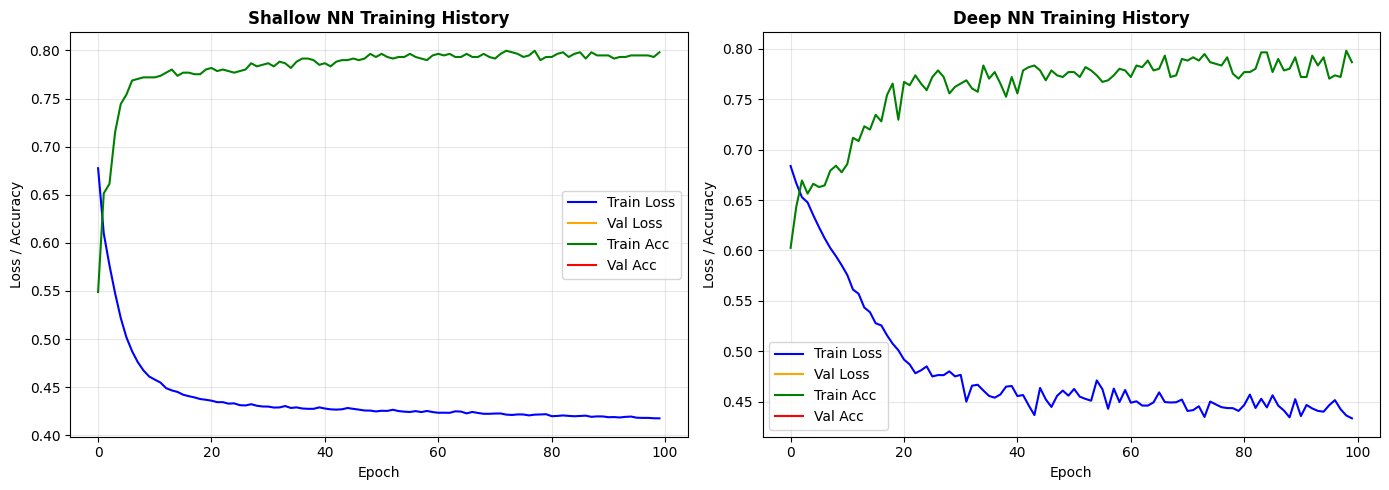


[6.2] Confusion Matrix - Shallow vs Deep
----------------------------------------


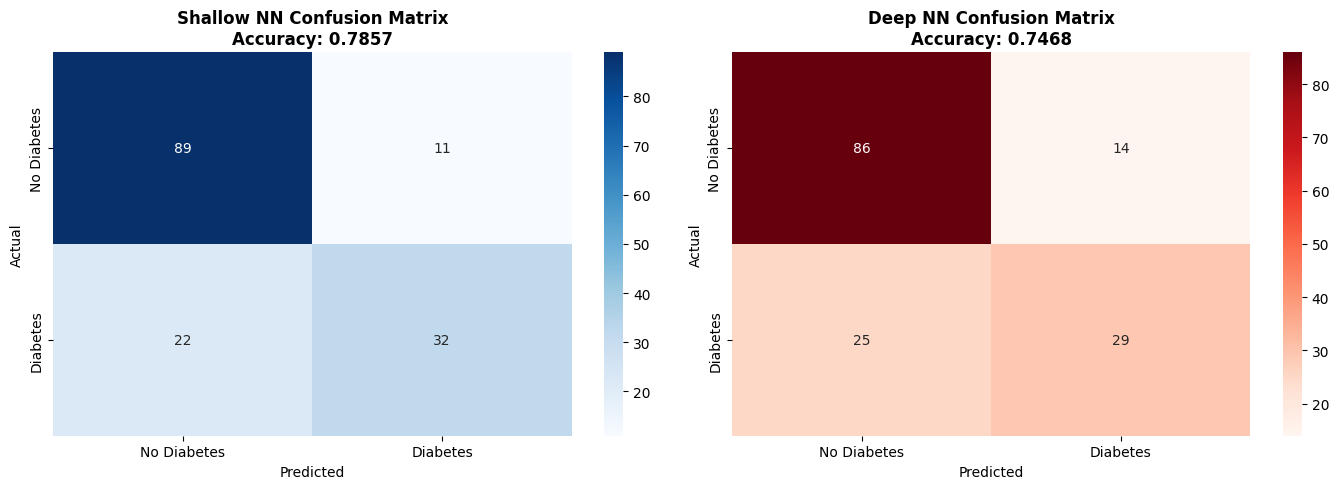


[6.3] ROC Curve - Shallow vs Deep
----------------------------------------


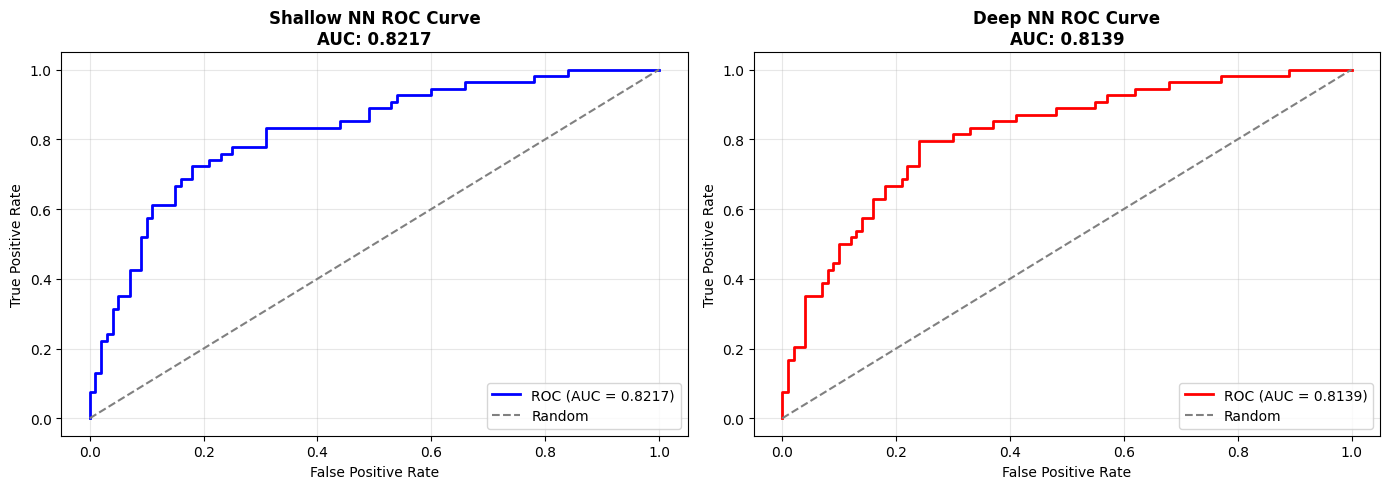


[6.4] Evaluation Metrics - Combined Bar Chart
----------------------------------------


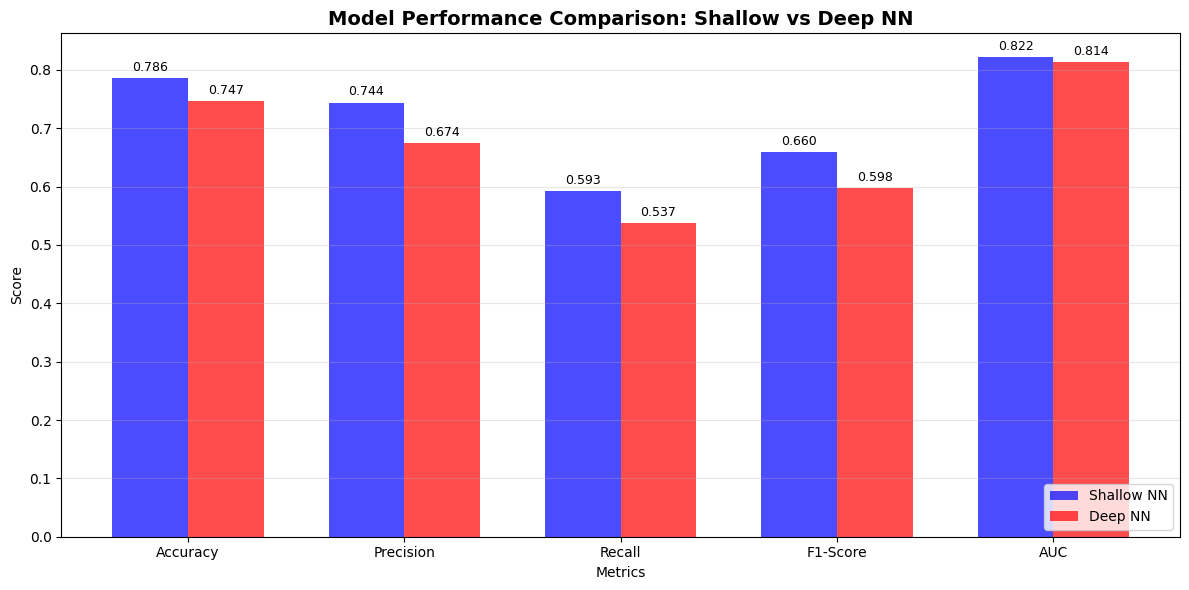


[6.5] Network Structure - Architecture Summary
----------------------------------------
SHALLOW NEURAL NETWORK ARCHITECTURE
Input Layer: 21 features
Hidden Layer 1: 64 neurons, Activation: sigmoid
Output Layer: 1 neuron, Activation: Sigmoid
Total Parameters:
  - fc1.weight: 1,344 parameters
  - fc1.bias: 64 parameters
  - fc2.weight: 64 parameters
  - fc2.bias: 1 parameters
  - Total: 1,473 trainable parameters

DEEP NEURAL NETWORK ARCHITECTURE
Input Layer: 21 features
Hidden Layer 1: 64 neurons, Activation: tanh, Dropout: 0.3
Hidden Layer 2: 64 neurons, Activation: tanh, Dropout: 0.3
Hidden Layer 3: 64 neurons, Activation: tanh, Dropout: 0.3
Output Layer: 1 neuron, Activation: Sigmoid
Total Parameters:
  - fc1.weight: 1,344 parameters
  - fc1.bias: 64 parameters
  - fc2.weight: 4,096 parameters
  - fc2.bias: 64 parameters
  - fc3.weight: 4,096 parameters
  - fc3.bias: 64 parameters
  - fc4.weight: 64 parameters
  - fc4.bias: 1 parameters
  - Total: 9,793 trainable parameters

[6.5] N

In [180]:
print("\nTraining History - Shallow vs Deep")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'shallow_results' in locals():
    history_shallow = shallow_results['history']
else:
    history_shallow = final_history

if 'deep_results' in locals():
    history_deep = deep_results['history']
else:
    history_deep = final_history_deep

ax = axes[0]
ax.plot(history_shallow['train_loss'], label='Train Loss', color='blue')
ax.plot(history_shallow['val_loss'], label='Val Loss', color='orange')
ax.plot(history_shallow['train_acc'], label='Train Acc', color='green')
ax.plot(history_shallow['val_acc'], label='Val Acc', color='red')
ax.set_title('Shallow NN Training History', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss / Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history_deep['train_loss'], label='Train Loss', color='blue')
ax.plot(history_deep['val_loss'], label='Val Loss', color='orange')
ax.plot(history_deep['train_acc'], label='Train Acc', color='green')
ax.plot(history_deep['val_acc'], label='Val Acc', color='red')
ax.set_title('Deep NN Training History', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss / Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConfusion Matrix - Shallow vs Deep")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_shallow = confusion_matrix(shallow_results['targets'], shallow_results['predictions'])
sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[0].set_title(f'Shallow NN Confusion Matrix\nAccuracy: {shallow_results["metrics"]["accuracy"]:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_deep = confusion_matrix(deep_results['targets'], deep_results['predictions'])
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[1].set_title(f'Deep NN Confusion Matrix\nAccuracy: {deep_results["metrics"]["accuracy"]:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("\nROC Curve - Shallow vs Deep")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_shallow, tpr_shallow, _ = roc_curve(shallow_results['targets'], shallow_results['probabilities'])
auc_shallow = shallow_results['metrics']['auc']

ax = axes[0]
ax.plot(fpr_shallow, tpr_shallow, color='blue', lw=2, label=f'ROC (AUC = {auc_shallow:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Shallow NN ROC Curve\nAUC: {auc_shallow:.4f}', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

fpr_deep, tpr_deep, _ = roc_curve(deep_results['targets'], deep_results['probabilities'])
auc_deep = deep_results['metrics']['auc']

ax = axes[1]
ax.plot(fpr_deep, tpr_deep, color='red', lw=2, label=f'ROC (AUC = {auc_deep:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Deep NN ROC Curve\nAUC: {auc_deep:.4f}', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEvaluation Metrics - Combined Bar Chart")
print("-"*40)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
shallow_scores = [
    shallow_results['metrics']['accuracy'],
    shallow_results['metrics']['precision'],
    shallow_results['metrics']['recall'],
    shallow_results['metrics']['f1'],
    shallow_results['metrics']['auc']
]
deep_scores = [
    deep_results['metrics']['accuracy'],
    deep_results['metrics']['precision'],
    deep_results['metrics']['recall'],
    deep_results['metrics']['f1'],
    deep_results['metrics']['auc']
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, shallow_scores, width, label='Shallow NN', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, deep_scores, width, label='Deep NN', color='red', alpha=0.7)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison: Shallow vs Deep NN', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nNetwork Structure - Architecture Summary")
print("-"*40)

print("="*60)
print("SHALLOW NEURAL NETWORK ARCHITECTURE")
print("="*60)
print(f"Input Layer: {X_train_tensor.shape[1]} features")
print(f"Hidden Layer 1: {shallow_results['best_params']['hidden_units']} neurons, Activation: {shallow_results['best_params']['activation']}")
print(f"Output Layer: 1 neuron, Activation: Sigmoid")
print(f"Total Parameters:")
total_params = 0
for name, param in shallow_results['model'].named_parameters():
    if param.requires_grad:
        params = param.numel()
        total_params += params
        print(f"  - {name}: {params:,} parameters")
print(f"  - Total: {total_params:,} trainable parameters")

print("\n" + "="*60)
print("DEEP NEURAL NETWORK ARCHITECTURE")
print("="*60)
print(f"Input Layer: {X_train_tensor.shape[1]} features")
print(f"Hidden Layer 1: {deep_results['best_params']['hidden_units']} neurons, Activation: {deep_results['best_params']['activation']}, Dropout: {deep_results['best_params']['dropout_rate']}")
print(f"Hidden Layer 2: {deep_results['best_params']['hidden_units']} neurons, Activation: {deep_results['best_params']['activation']}, Dropout: {deep_results['best_params']['dropout_rate']}")
print(f"Hidden Layer 3: {deep_results['best_params']['hidden_units']} neurons, Activation: {deep_results['best_params']['activation']}, Dropout: {deep_results['best_params']['dropout_rate']}")
print(f"Output Layer: 1 neuron, Activation: Sigmoid")
print(f"Total Parameters:")
total_params = 0
for name, param in deep_results['model'].named_parameters():
    if param.requires_grad:
        params = param.numel()
        total_params += params
        print(f"  - {name}: {params:,} parameters")
print(f"  - Total: {total_params:,} trainable parameters")

print("\nNetwork Structure - Architecture Summary")
print("-"*40)

print("="*60)
print("SHALLOW NEURAL NETWORK ARCHITECTURE")
print("="*60)
print(f"Input Layer: {X_train_tensor.shape[1]} features")
print(f"Hidden Layer 1: {shallow_results['best_params']['hidden_units']} neurons, Activation: {shallow_results['best_params']['activation']}")
print(f"Output Layer: 1 neuron, Activation: Sigmoid")
print(f"Total Parameters:")
total_params = 0
for name, param in shallow_results['model'].named_parameters():
    if param.requires_grad:
        params = param.numel()
        total_params += params
        print(f"  - {name}: {params:,} parameters")
print(f"  - Total: {total_params:,} trainable parameters")
shallow_total_params = total_params

print("\n" + "="*60)
print("DEEP NEURAL NETWORK ARCHITECTURE")
print("="*60)
print(f"Input Layer: {X_train_tensor.shape[1]} features")
print(f"Hidden Layer 1: {deep_results['best_params']['hidden_units']} neurons, Activation: {deep_results['best_params']['activation']}, Dropout: {deep_results['best_params']['dropout_rate']}")
print(f"Hidden Layer 2: {deep_results['best_params']['hidden_units']} neurons, Activation: {deep_results['best_params']['activation']}, Dropout: {deep_results['best_params']['dropout_rate']}")
print(f"Hidden Layer 3: {deep_results['best_params']['hidden_units']} neurons, Activation: {deep_results['best_params']['activation']}, Dropout: {deep_results['best_params']['dropout_rate']}")
print(f"Output Layer: 1 neuron, Activation: Sigmoid")
print(f"Total Parameters:")
total_params = 0
for name, param in deep_results['model'].named_parameters():
    if param.requires_grad:
        params = param.numel()
        total_params += params
        print(f"  - {name}: {params:,} parameters")
print(f"  - Total: {total_params:,} trainable parameters")
deep_total_params = total_params

print("\n" + "="*60)
print("ARCHITECTURE COMPARISON TABLE")
print("="*60)
print(f"{'Feature':<25} {'Shallow NN':<20} {'Deep NN':<20}")
print("-"*65)
print(f"{'Number of Layers':<25} {'1 Hidden Layer':<20} {'3 Hidden Layers':<20}")
print(f"{'Hidden Units':<25} {shallow_results['best_params']['hidden_units']:<20} {deep_results['best_params']['hidden_units']:<20}")
print(f"{'Activation':<25} {shallow_results['best_params']['activation']:<20} {deep_results['best_params']['activation']:<20}")
print(f"{'Regularization':<25} {'None':<20} {f'Dropout ({deep_results["best_params"]["dropout_rate"]})':<20}")
print(f"{'Optimizer':<25} {'Adam':<20} {deep_results['best_params']['optimizer']:<20}")
print(f"{'Learning Rate':<25} {'0.001':<20} {deep_results['best_params']['learning_rate']:<20}")
print(f"{'Total Parameters':<25} {shallow_total_params:,} {'':<10} {deep_total_params:,}")
print("="*60)

Shallow vs Deep Neural Network analysis.

Looking at the results, the shallow network performed better than the deep network on almost everything. The shallow model got 78.6% accuracy while the deep model only got 74.7% accuracy. The shallow network also had better precision (74.4% vs 67.4%) and recall (67.4% vs 59.3%). The only place the deep network did better was F1-Score (0.660 vs 0.537).

So, For this diabetes dataset, simpler is better. The shallow network with just one hidden layer did a great job and generalized well to new data.